<div style="text-align:center;">
    <h1><b style="color:black">Automated Classification of Dry Bean Types</b></h1>
    <h3 style="color:black">Nur Bozdemir</h3>
    <br>
</div>

**Scenario:**

In the agricultural sector, dry bean producers face the challenge of identifying and classifying various bean types based on their physical attributes. Manual classification methods are time-consuming, inefficient, and prone to errors, especially when bean types exhibit subtle differences in physical properties.

To address this challenge, I propose the development of a machine learning model that automates the classification of different bean types. The model will utilize measurable physical features such as area, perimeter, and compactness to accurately and efficiently categorize the beans.

**Goal:**

The primary goal is to enable accurate **classification**, allowing producers to optimize product packaging, improve inventory management, and enhance marketing strategies, all while reducing human labor and minimizing errors.

**Value of the Project**

Economic Value:

Accurate classification minimizes mislabeling and inventory errors, leading to significant cost reductions.
Enhanced product accuracy builds customer trust and strengthens brand reputation, which can drive increased revenue.

Operational Value:

Automation accelerates the sorting process, enabling producers to handle larger volumes of beans more efficiently.
It reduces reliance on manual labor and minimizes human error, ensuring consistent product quality across shipments.

**Quality Metrics**

**1. Accuracy:**

 It provides a straightforward and interpretable metric, especially when the dataset is balanced across different classes.

**2. F1 Score:**

 Particularly effective for imbalanced datasets, as it balances performance across all classes, ensuring that minority bean types are also classified accurately.



 This project addresses a **classification problem**, as the goal is to assign each dry bean to one of the seven registered categories, such as "SEKER" or "DERMASON". The target variable is categorical, making classification the most appropriate approach.








The Dry Bean Dataset was downloaded from the UCI(University of California, Irvine (UCI) Machine Learning Repository
https://archive.ics.uci.edu/dataset/602/dry+bean+dataset)

License Information
The dataset is licensed under the Creative Commons Attribution 4.0 International (CC BY 4.0) license.
What it allows: Sharing and adaptation for any purpose, including commercial use.


<div style="text-align: center;">
    <h3 style="color: black; font-weight: bold;"> The Data</h3>
</div>


In [1]:
import pandas as pd
path="Dry_Bean_Dataset.xlsx"
df=pd.read_excel(path)
df.head(2)

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER


**Dataset Description:**

The dataset contains numerical measurements of 13,611 grains from 7 different registered dry bean types. These types include *SEKER*, *DERMASON*, *SIRA*, *CALI*, *HOROZ*, *BARBUNYA*, and *BOMBAY*. Each instance in the dataset represents a single dry bean, described by 16 features.

**Features:**

**Numeric Features:**

**Area:** Represents the surface area of the bean.

**Perimeter:** The total length around the bean's edge.

**MajorAxisLength:** The longest diameter across the bean's shape.

**MinorAxisLength:** The shortest diameter across the bean's shape.

**AspectRation:** Ratio of the major axis to the minor axis, indicating shape elongation.

**Eccentricity:** Describes how much the bean shape deviates from being circular.

**ConvexArea:** The area of the convex hull, capturing the smallest convex boundary.

**EquivDiameter:** The diameter of a circle with the same area as the bean.

**Extent:** The ratio of the bean’s area to its bounding box area, showing space utilization.

**Solidity:** Proportion of the bean's area to its convex area, indicating compactness.

**Roundness:** Measures how circular the bean is.

**Compactness:** Describes how dense or compact the bean shape is.

**ShapeFactor1 to ShapeFactor4:** Additional geometric properties describing the bean's shape.

**Target Variable:**

**Class:** A categorical variable representing the type of bean (*SEKER*, *DERMASON*, *SIRA*, *CALI*, *HOROZ*, *BARBUNYA*, and *BOMBAY*).


**Why is this dataset suitable for my project?**

The aim of this project is to build a classification model that identifies the type of each dry bean. The dataset supports this goal because it includes a Class variable with 7 unique categories, representing different bean types.

The dataset contains 16 numerical features, including measurements of size, shape, and other physical properties of beans. These features are diverse and provide enough information to distinguish between the different bean types, making the dataset suitable for classification tasks.

With 13,611 data points, the dataset is large enough to train and test machine learning models effectively. The inclusion of multiple bean types ensures that the dataset is diverse.

The dataset is relevant to real-world problems faced by dry bean producers. It includes physical measurements that can be used for automated classification, solving practical issues in agriculture.



<div style="text-align: center;">
    <h3 style="color: black; font-weight: bold;">Initial Data Analysis</h3>
</div>

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import math
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import validation_curve
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold
from sklearn.metrics import accuracy_score, f1_score, make_scorer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
from sklearn.model_selection import GridSearchCV, KFold


In [3]:
df.head(2)

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER


In [4]:
df.shape

(13611, 17)

In [5]:
df.dtypes 
## The categorical data, 'Class,' will be converted to numerical values in task 4.

Area                 int64
Perimeter          float64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRation       float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Solidity           float64
roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class               object
dtype: object

In [6]:
df.isnull().sum() 
#There are no missing values in the dataset 

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

In [7]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [8]:
df['Class'].unique() 

array(['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON'],
      dtype=object)

In [9]:
df['Class'].value_counts()

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

**Distribution of Beans**

    ●The dataset has 13,611 samples and 7 types of dry beans.
    ●The most common is DERMASON with 3,546 samples, while BOMBAY has the least, only 522 samples.
    ●This imbalance might make it harder to classify rare types like BOMBAY.


In [10]:
colurs= {
    'DERMASON':'green',
    'SIRA':'brown',
    'SEKER':'yellow',
    'HOROZ':'pink',
    'CALI':'blue',
    'BARBUNYA':'purple',
    'BOMBAY':'red'

}

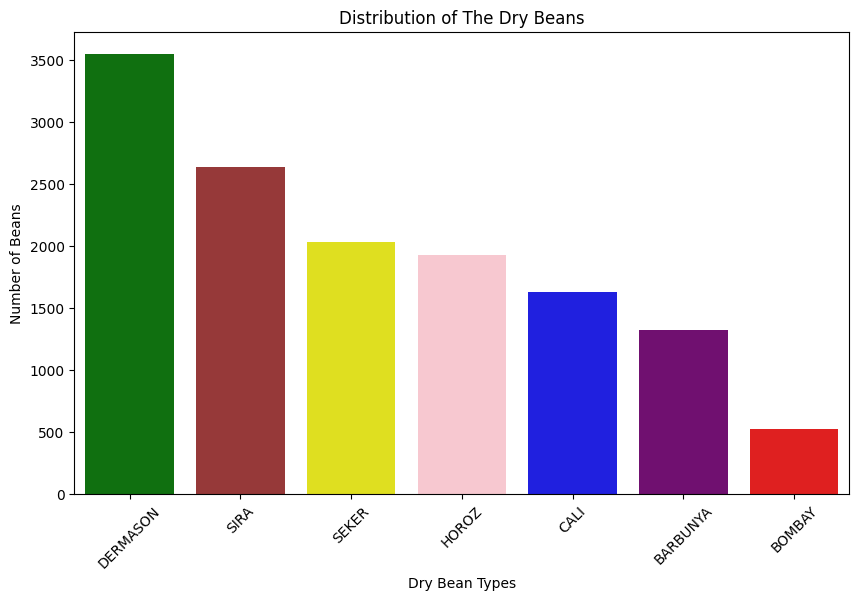

In [11]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Class', data=df, order=df['Class'].value_counts().index,hue='Class',palette=colurs)
plt.title('Distribution of The Dry Beans')
plt.xlabel('Dry Bean Types')
plt.ylabel('Number of Beans')
plt.xticks(rotation=45)
plt.show()

In [12]:
label_encoder = LabelEncoder()

df['Class_encoded'] = label_encoder.fit_transform(df['Class'])  

df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class,Class_encoded
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER,5
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER,5
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER,5
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER,5
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER,5


**Encoding the "Class" Column**

    ●Bean types were converted into numbers. For example, SEKER is 5, and DERMASON is 3.
    ●This step is necessary because machine learning algorithms need numbers
    


In [13]:
class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Class Mapping:")
print(class_mapping)

Class Mapping:
{'BARBUNYA': 0, 'BOMBAY': 1, 'CALI': 2, 'DERMASON': 3, 'HOROZ': 4, 'SEKER': 5, 'SIRA': 6}


In [14]:
encoded_colours = {
    0: 'purple',  # BARBUNYA
    1: 'red',     # BOMBAY
    2: 'blue',    # CALI
    3: 'green',   # DERMASON
    4: 'pink',    # HOROZ
    5: 'yellow',  # SEKER
    6: 'brown'    # SIRA
}


In [15]:
df=df.drop('Class',axis='columns')
#I created a new column  above named 'Class_encoded' and dropped the 'Class' column as it contained categorical data.
df.head(1)

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class_encoded
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,5


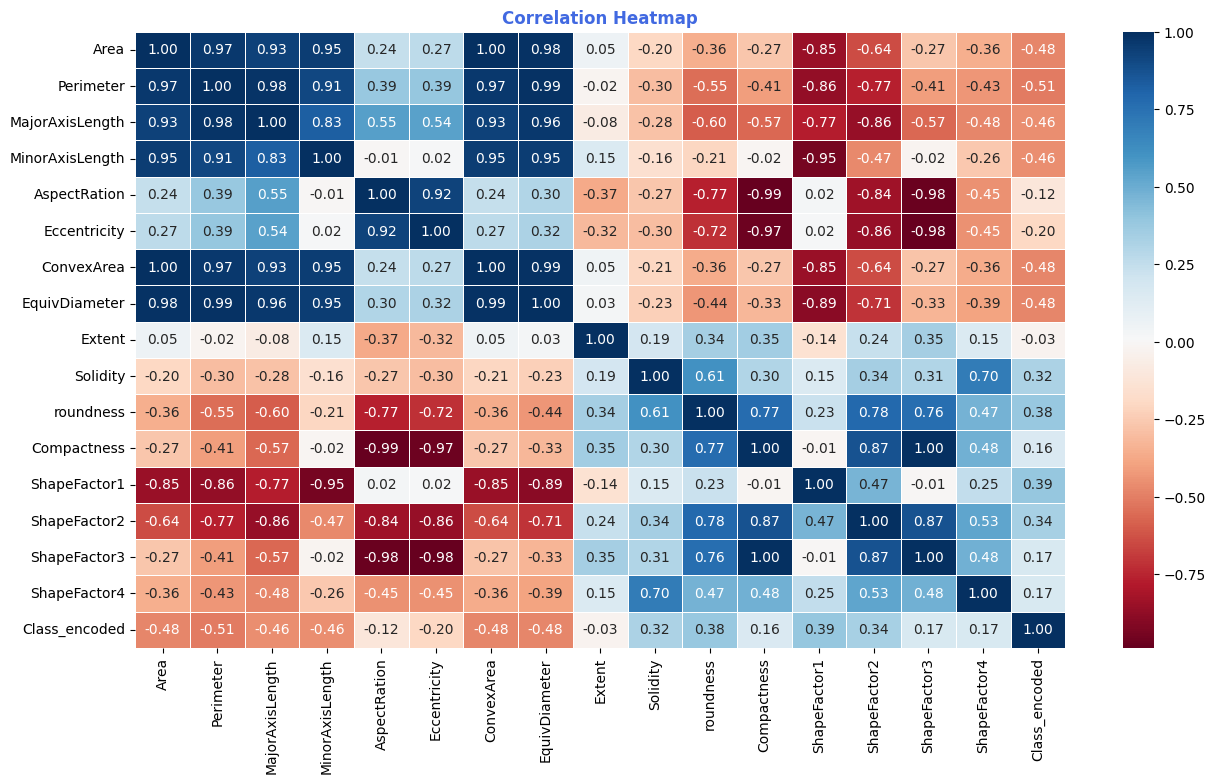

In [16]:
corr_matrix = df.corr()

plt.figure(figsize=(15, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap',color='royalblue',weight='bold')
plt.show()

**Comments for Correlation Matrix**

*The correlation heatmap shows strong positive correlations between features like Area and ConvexArea (1), and Perimeter and MajorAxisLength (0.98), which indicate redundancy in these variables. Conversely, features such as Extent and AspectRation (-0.37) show low correlations with others, suggesting their unique contribution to the dataset. These insights can guide feature selection or dimensionality reduction steps to enhance model performance*
    


<div style="text-align: center;">
    <h3 style="color: black; font-weight: bold;">EDA and Preprocessing</h3>
</div>

In [17]:
df.head(1)

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class_encoded
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,5


In [18]:

df.isnull().sum()
##We have already seen that there were no missing values in Task 3, but I added the code again


Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class_encoded      0
dtype: int64

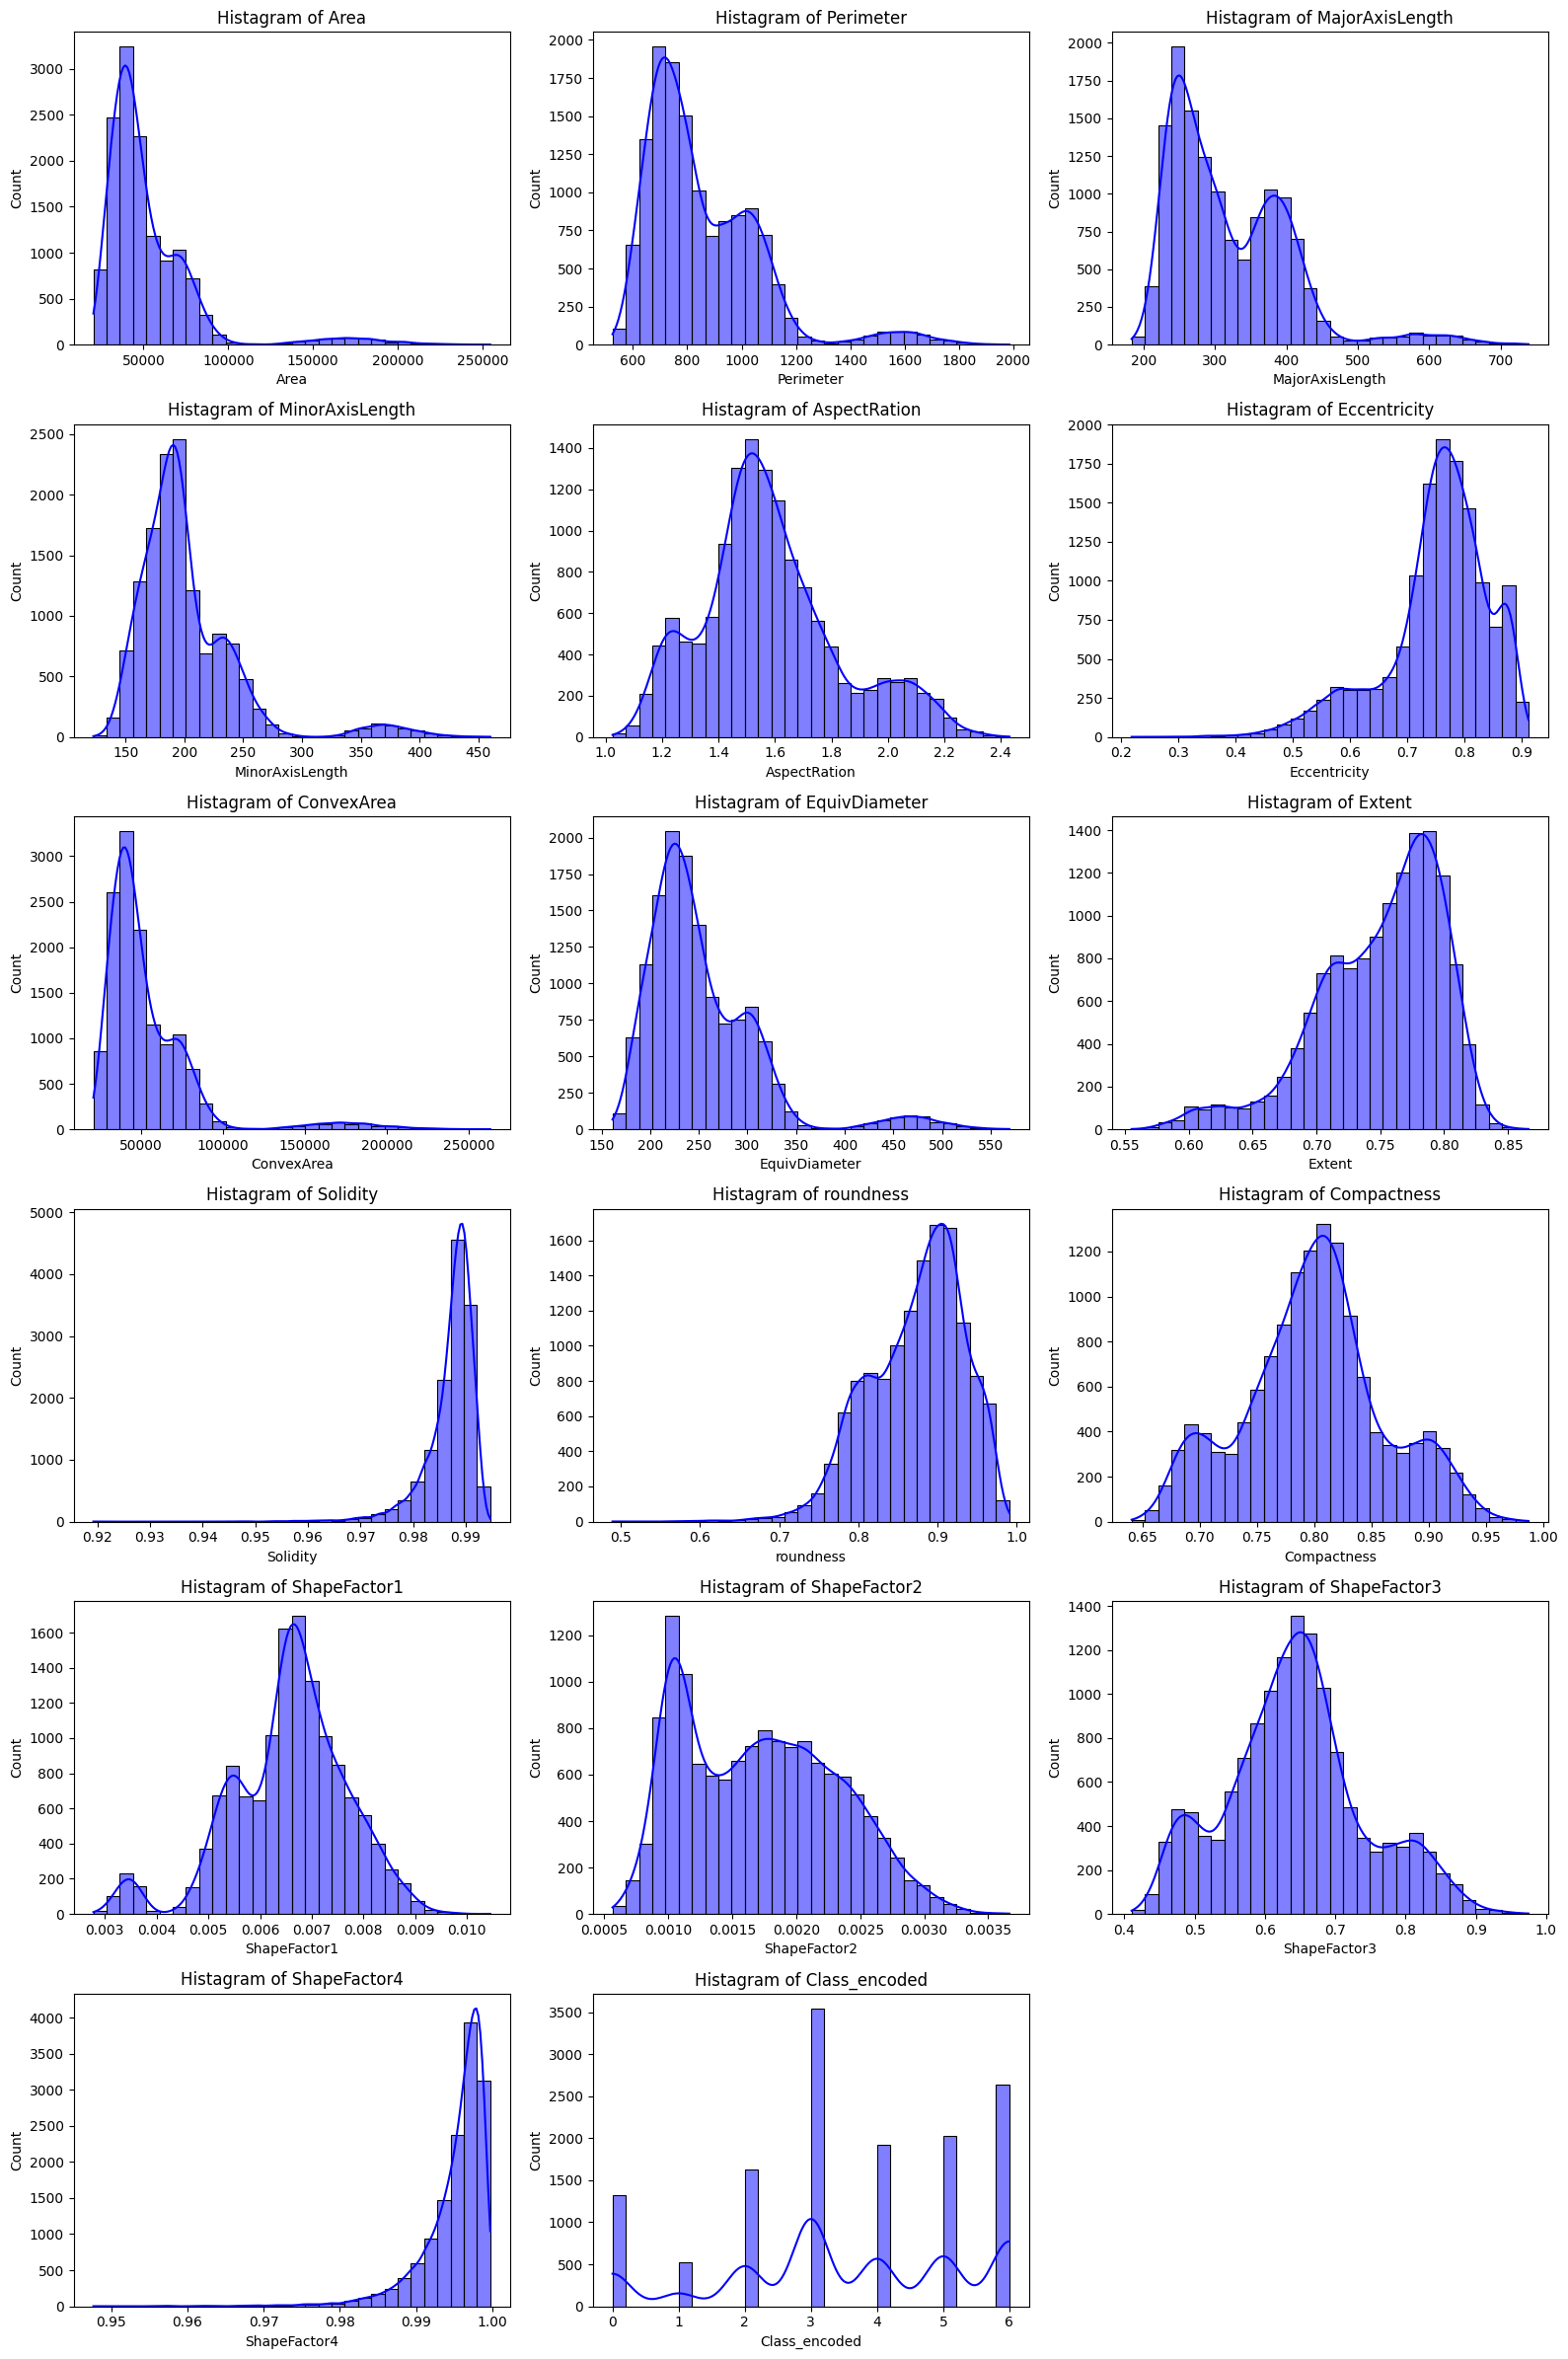

In [19]:
# Numeric columns
numeric_features = df.select_dtypes(include=['int64', 'float64', 'int32']).columns

# Calculate the number of rows and columns for the grid
num_features = len(numeric_features)
num_cols = 3  
num_rows = math.ceil(num_features / num_cols)  

# Create the grid
fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, num_rows * 4))

# Loop through each numeric feature and create a histogram
for i, feature in enumerate(numeric_features):
    row, col = divmod(i, num_cols) 
    sns.histplot(df[feature], kde=True, bins=30, ax=axes[row, col], color="blue")
    axes[row, col].set_title(f'Histagram of {feature}')
    
    
for i in range(num_features, num_rows * num_cols):
    fig.delaxes(axes.flat[i])

plt.tight_layout()
plt.show()


**Outliers:**

    ●Features like Area, ConvexArea have extreme values.
    ●The IQR method or log transformation can be used to mitigate their impact.
    ●I will check the outliers in detail in next steps.


**Class Encoded:**

    ● The bar graph reveals that some classes (e.g., Class 3) dominate, while others (e.g., Class 1) are underrepresented.
    ●This imbalance in the Class Encoded feature could lead to biased models
    ●This could lead to biased models that favor larger classes. Techniques like oversampling or class weight adjustments might be necessary to address this issue.


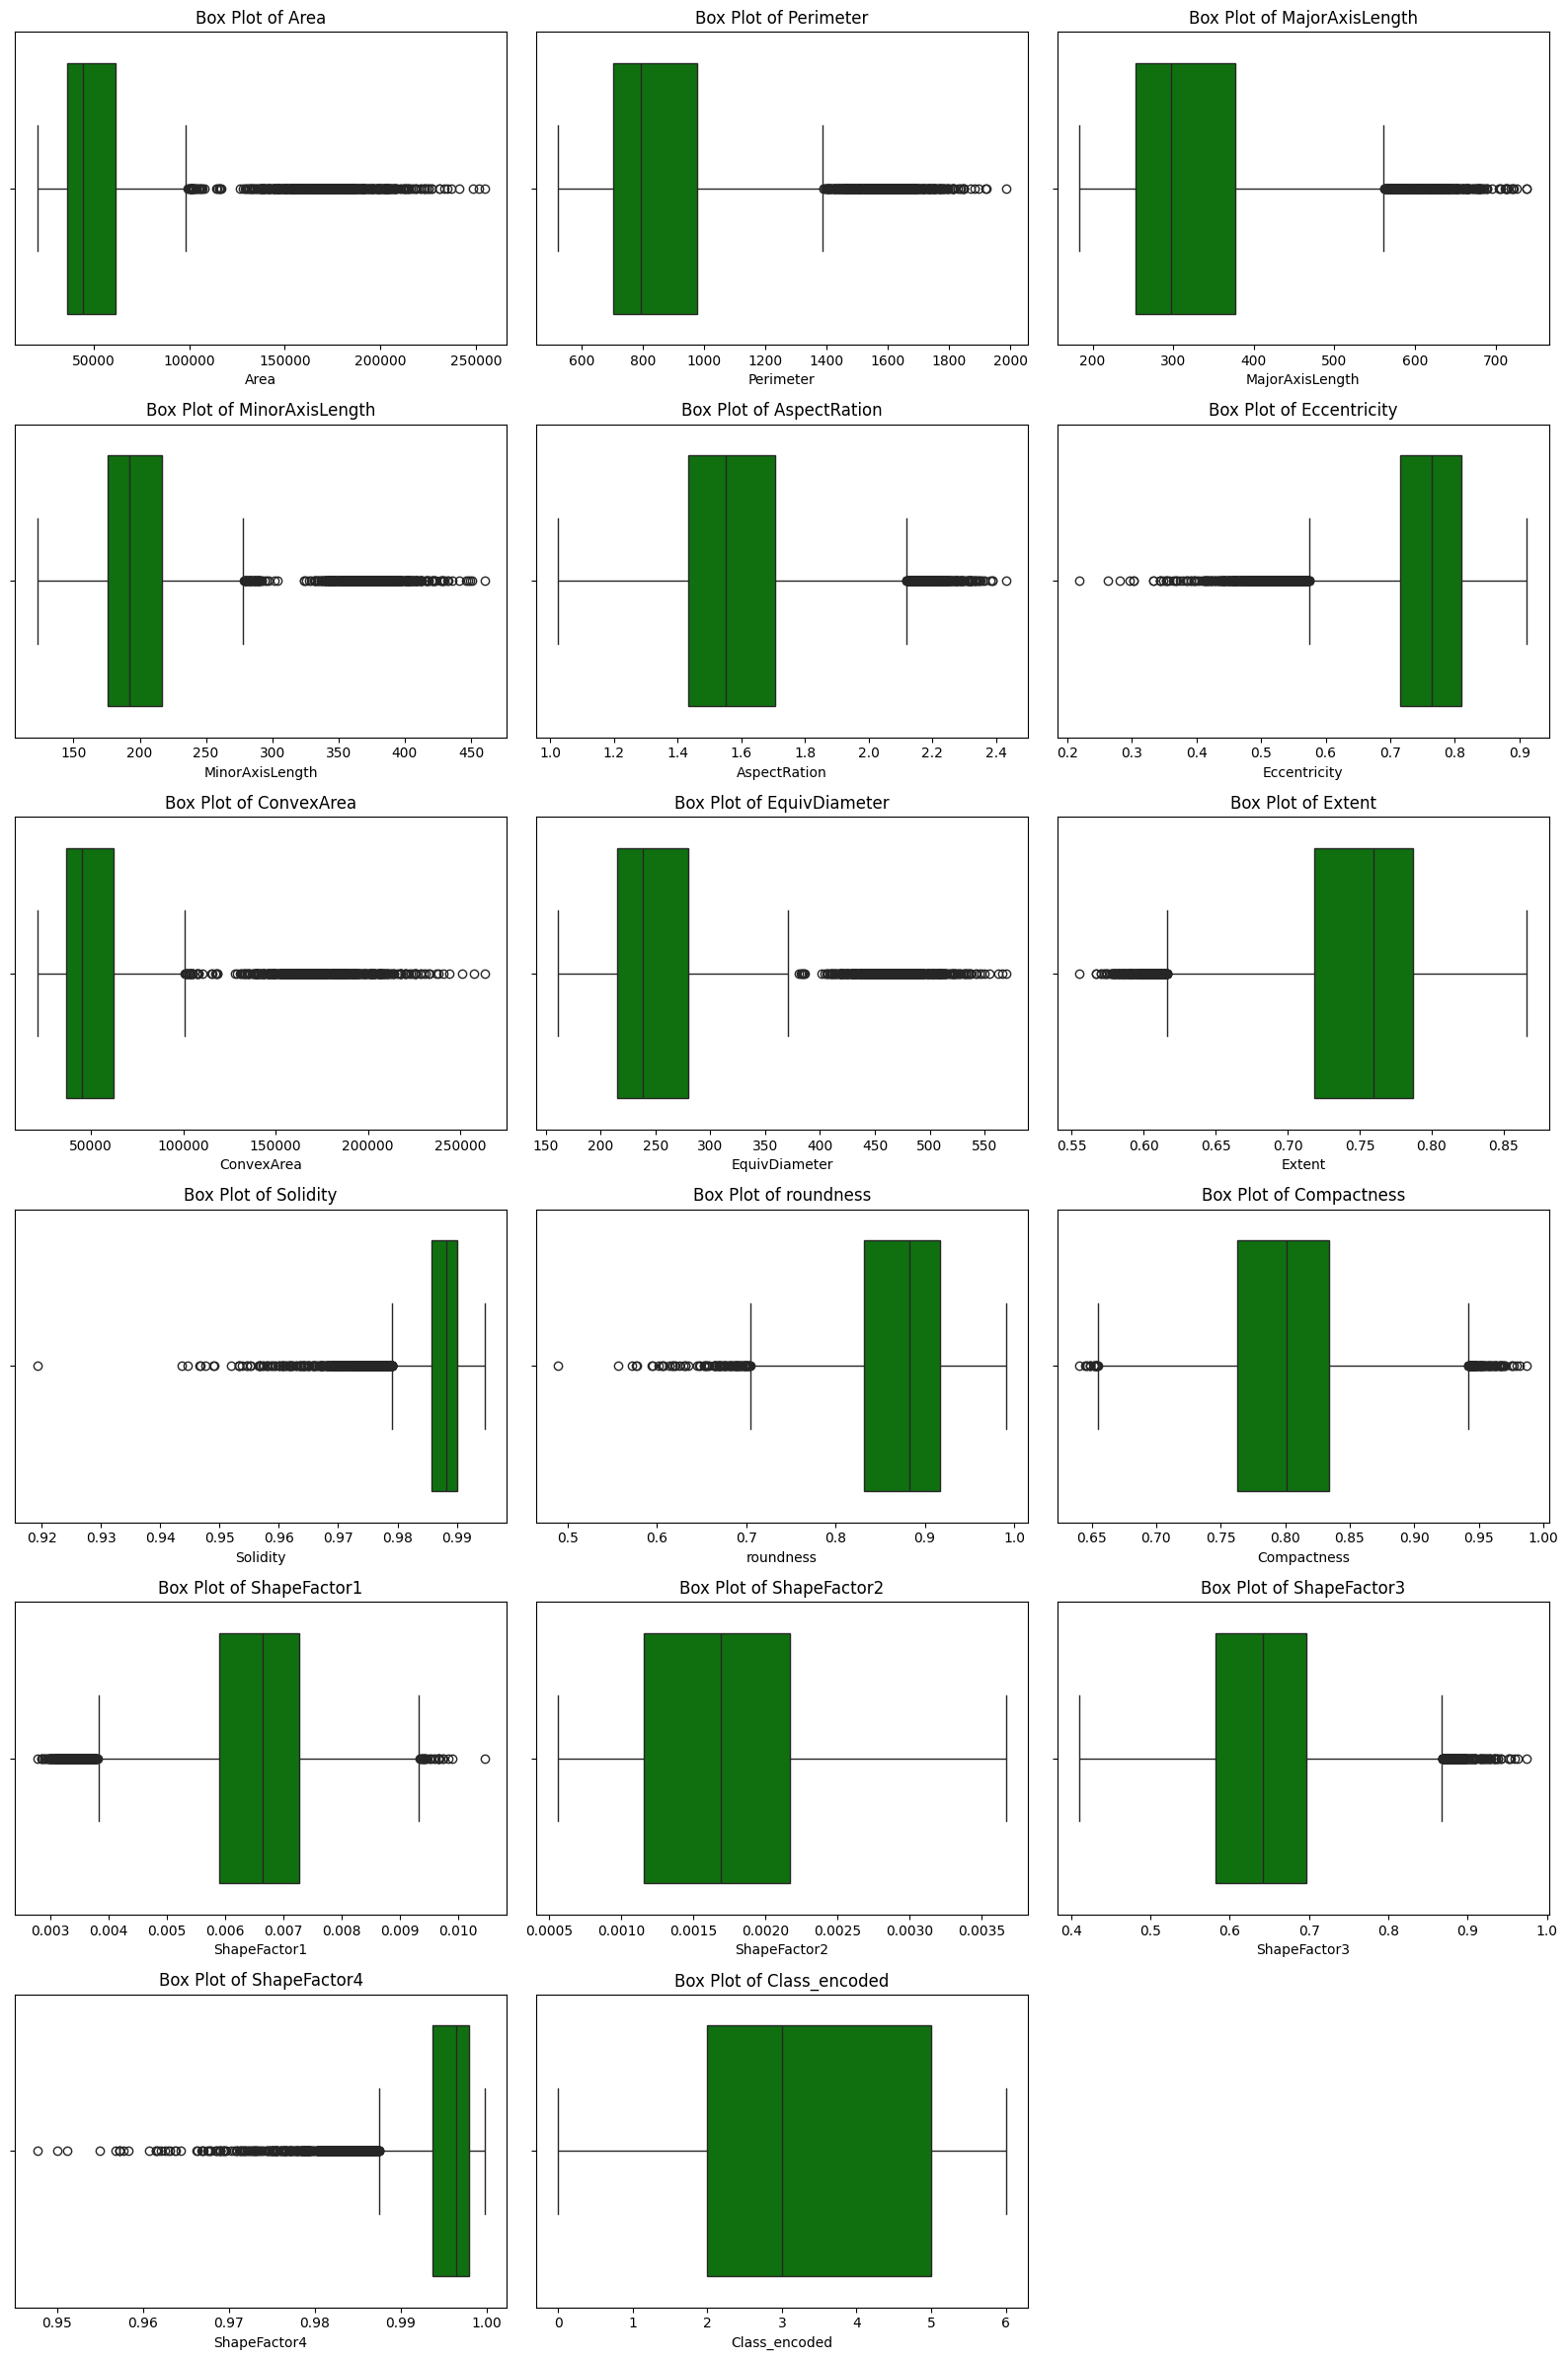

In [20]:

# Determine the number of rows and columns for the grid
num_features = len(numeric_features)
num_cols = 3  
num_rows = math.ceil(num_features / num_cols) 

# Create the grid for subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, num_rows * 4))

# Plot each feature in the grid
for i, feature in enumerate(numeric_features):
    row, col = divmod(i, num_cols)  
    sns.boxplot(x=df[feature], ax=axes[row, col], color="green")
    axes[row, col].set_title(f'Box Plot of {feature}')

# Remove any empty subplots if the grid is larger than the number of features
for i in range(num_features, num_rows * num_cols):
    fig.delaxes(axes.flat[i])


plt.tight_layout()
plt.show()


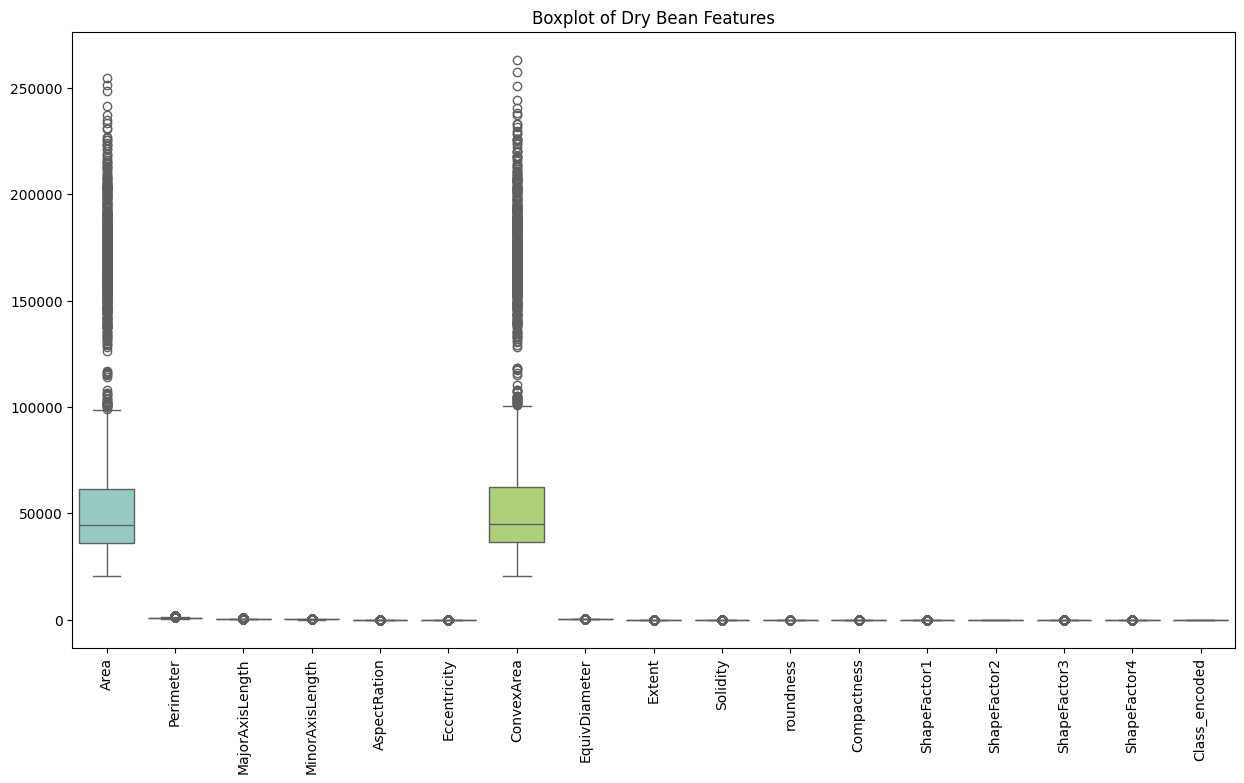

In [21]:
# Visualizing outliers for all columns in the DataFrame
plt.figure(figsize=(15, 8))
sns.boxplot(data=df, palette="Set3")
plt.title("Boxplot of Dry Bean Features")
plt.xticks(rotation=90)
plt.show()


**Outliers Identified::**

    ● Features like Area and ConvexArea have extreme values, as visible in the boxplots above.
    ●These outliers were flagged for removal in the next step.
   

In [22]:

# Function to calculate outliers based on IQR
def detect_outliers(df, feature):
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    return outliers

# Analyze outliers for each numeric column
outlier_summary = {}
for feature in numeric_features:  
    outliers = detect_outliers(df, feature)
    outlier_summary[feature] = {
        "Outlier Count": len(outliers),
        "Outlier Percentage": len(outliers) / len(df) * 100,
    }

# Display outlier analysis
outlier_df = pd.DataFrame(outlier_summary).T
outlier_df = outlier_df.sort_values(by="Outlier Percentage", ascending=False)

print("Outlier Analysis Summary:\n", outlier_df)


Outlier Analysis Summary:
                  Outlier Count  Outlier Percentage
Eccentricity             843.0            6.193520
Solidity                 778.0            5.715965
ShapeFactor4             767.0            5.635148
MinorAxisLength          569.0            4.180442
Area                     551.0            4.048196
ConvexArea               550.0            4.040849
ShapeFactor1             533.0            3.915950
EquivDiameter            526.0            3.864521
Perimeter                500.0            3.673499
AspectRation             473.0            3.475130
MajorAxisLength          379.0            2.784513
Extent                   275.0            2.020425
ShapeFactor3             195.0            1.432665
Compactness              109.0            0.800823
roundness                 91.0            0.668577
ShapeFactor2               0.0            0.000000
Class_encoded              0.0            0.000000


 **Comments about outlier Analysis Summary :**

 ● When I analyzed the outliers in more detail, I found that Eccentricity, Solidity, and ShapeFactor4 have a higher percentage of outliers.

 ●However, these outliers are minor deviations and remain close to the main range, making them less visible in the box plot.

 ●In the box plot, Area and ConvexArea have outliers with very big values. These outliers are far from the main range, so they are easy to notice.

 ●For this reason, I will remove the outliers in **Area** and **ConvexArea** in the next steps. These outliers affect the data more because they are very different from the other values.



**Summary of EDA and Preprocessing Steps**

 ***NOTE: This will be a general summary of what I have done. You have seen some parts of it so far, and the remaining sections will   be presented below.***  

 **Handling Missing Values:**

 ●There were no missing values in the dataset using df.isnull().sum(). This confirmed that no imputation or removal was necessary.

 **Outlier Detection and Removal**:

 ●Visualized **outliers** using boxplots above. 
 
 ●Identified significant outliers in the **Area** and **ConvexArea** features. 

 ●Outliers will be removed using the Interquartile Range (IQR) method, resulting in a new cleaned DataFrame **(df_cleaned)**.

 ●The class distribution (bean types) will be displayed using a bar chart with corresponding labels.


 **Feature Engineering:**

 ● A new feature, **Compactness_Feature**, will be added, calculated as Perimeter^2 / Area. This feature will provide additional geometric insights into the shape of the beans.


 **Data Summarization and Visualization:**

 ● Descriptive statistics for the cleaned dataset will be generated using .describe() and .info().

 ● The distributions of all features (histograms) will be visualized before and after outlier removal.

 ● A correlation matrix for the cleaned dataset will be created both before and after the addition of the new feature, **"Compactness_Feature"**.

 ●The class distribution (bean types) will be displayed using a bar chart with corresponding labels.



In [23]:
# Detecting and removing outliers using the IQR method

def remove_outliers_iqr(df, columns):
    for col in columns:
        
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

    
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

    
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    
    return df


numeric_columns = df.select_dtypes(include=['int64', 'float64', 'int32']).columns
df_cleaned = remove_outliers_iqr(df, numeric_columns)


print(f"Original dataset size: {df.shape}")
print(f"Size after removing outliers: {df_cleaned.shape}")



Original dataset size: (13611, 17)
Size after removing outliers: (10344, 17)


In [24]:
df_cleaned.shape

(10344, 17)

In [25]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10344 entries, 23 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             10344 non-null  int64  
 1   Perimeter        10344 non-null  float64
 2   MajorAxisLength  10344 non-null  float64
 3   MinorAxisLength  10344 non-null  float64
 4   AspectRation     10344 non-null  float64
 5   Eccentricity     10344 non-null  float64
 6   ConvexArea       10344 non-null  int64  
 7   EquivDiameter    10344 non-null  float64
 8   Extent           10344 non-null  float64
 9   Solidity         10344 non-null  float64
 10  roundness        10344 non-null  float64
 11  Compactness      10344 non-null  float64
 12  ShapeFactor1     10344 non-null  float64
 13  ShapeFactor2     10344 non-null  float64
 14  ShapeFactor3     10344 non-null  float64
 15  ShapeFactor4     10344 non-null  float64
 16  Class_encoded    10344 non-null  int32  
dtypes: float64(14), 

In [26]:
df_cleaned.head(1)

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class_encoded
23,31637,656.711,229.719255,175.510446,1.308864,0.645191,32045,200.702465,0.761823,0.987268,0.921842,0.873686,0.007261,0.00261,0.763327,0.999091,5


In [27]:
df_cleaned.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class_encoded
count,10344.000000,10344.000000,10344.000000,10344.000000,10344.000000,10344.000000,10344.000000,10344.000000,10344.000000,10344.000000,10344.000000,10344.000000,10344.000000,10344.000000,10344.000000,10344.000000,10344.000000
mean,46130.783546,803.653515,301.165011,191.700396,1.568731,0.754253,46696.735112,239.285620,0.751748,0.988115,0.882252,0.801731,0.006798,0.001777,0.645350,0.996052,3.714230
std,15201.235230,145.927401,60.676963,27.243210,0.204817,0.070602,15430.017649,38.445711,0.044333,0.002776,0.049190,0.050777,0.000927,0.000502,0.080910,0.002410,1.792409
min,20420.000000,524.736000,183.601165,138.867330,1.216650,0.569590,20684.000000,161.243764,0.612792,0.979243,0.740893,0.680445,0.004830,0.000816,0.463006,0.988972,0.000000
25%,35084.000000,692.975000,252.367272,172.188615,1.439599,0.719360,35489.250000,211.353581,0.719654,0.986633,0.851473,0.772581,0.006246,0.001349,0.596882,0.994679,3.000000
50%,42414.500000,770.755500,285.434611,188.644131,1.538729,0.760031,42878.500000,232.387217,0.758108,0.988559,0.891355,0.804743,0.006777,0.001791,0.647611,0.996673,3.000000
75%,53327.500000,900.807500,349.349675,204.508148,1.666468,0.799946,54003.250000,260.573755,0.787207,0.990052,0.917661,0.832206,0.007421,0.002168,0.692567,0.997919,5.000000
max,93235.000000,1199.087000,472.035963,264.610893,2.138584,0.883941,94031.000000,344.543885,0.866195,0.994260,0.980751,0.906257,0.009188,0.003312,0.821302,0.999733,6.000000


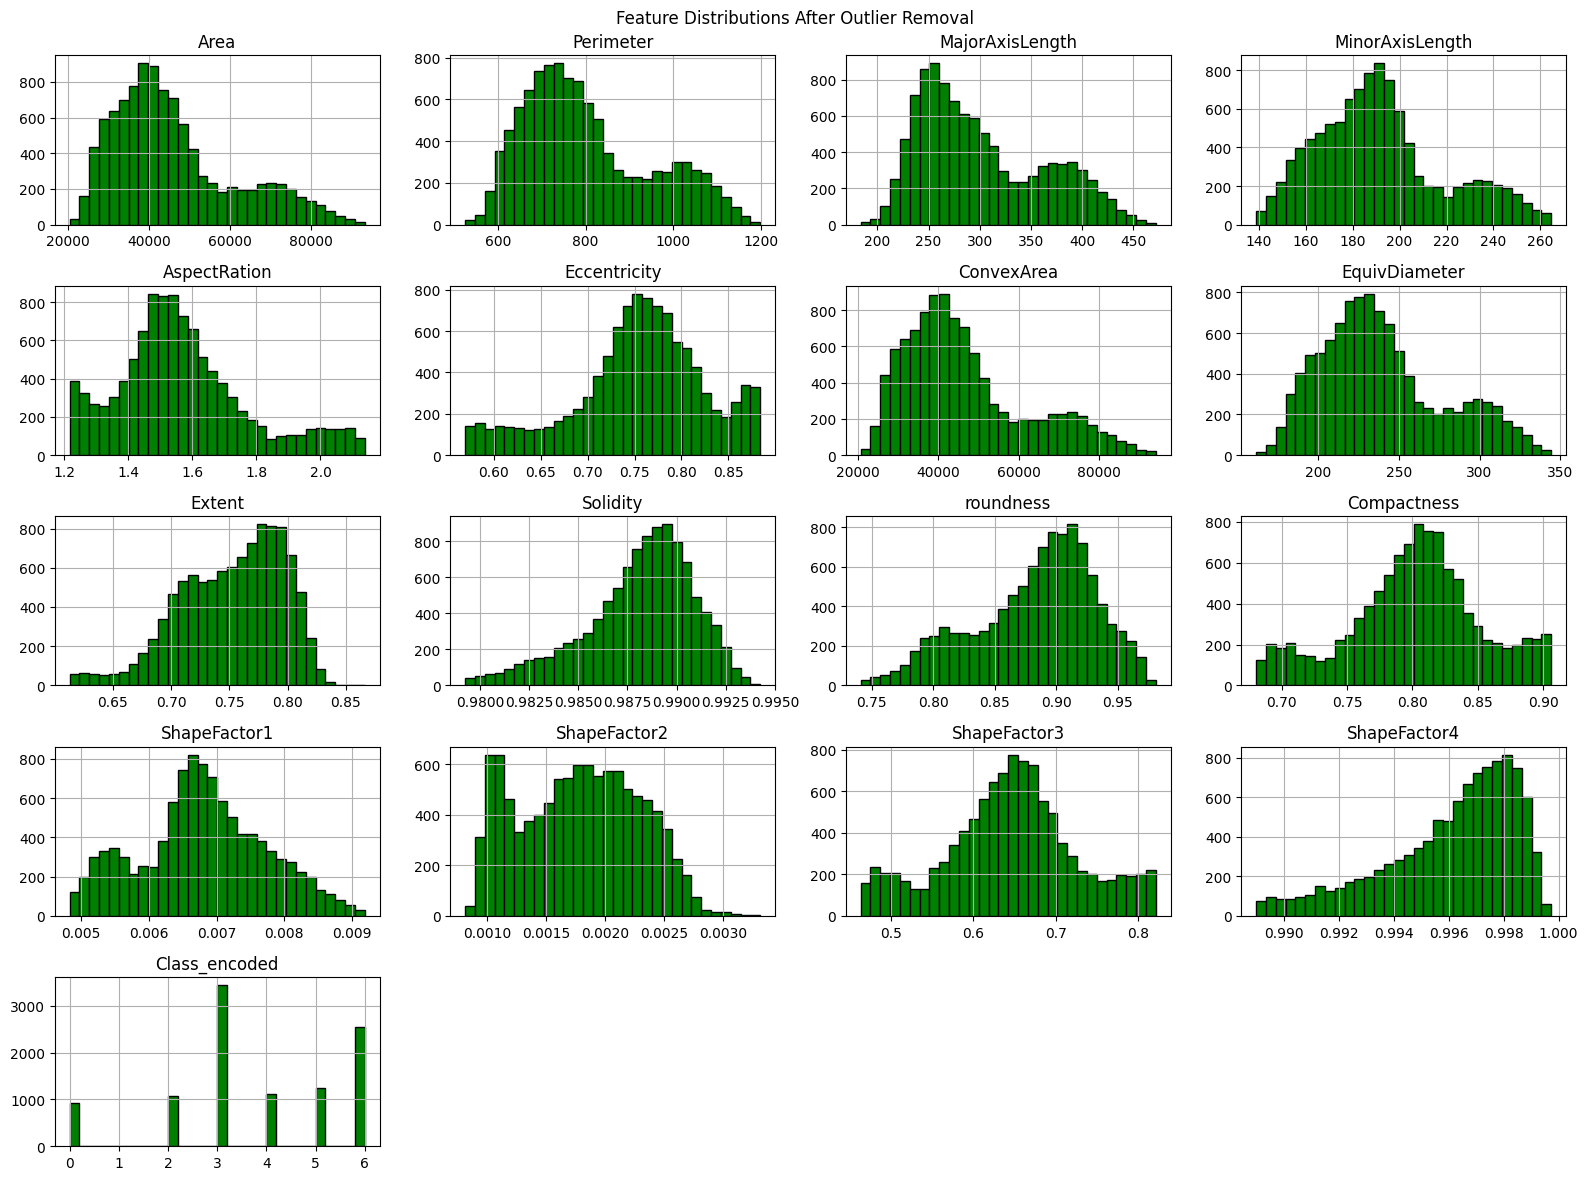

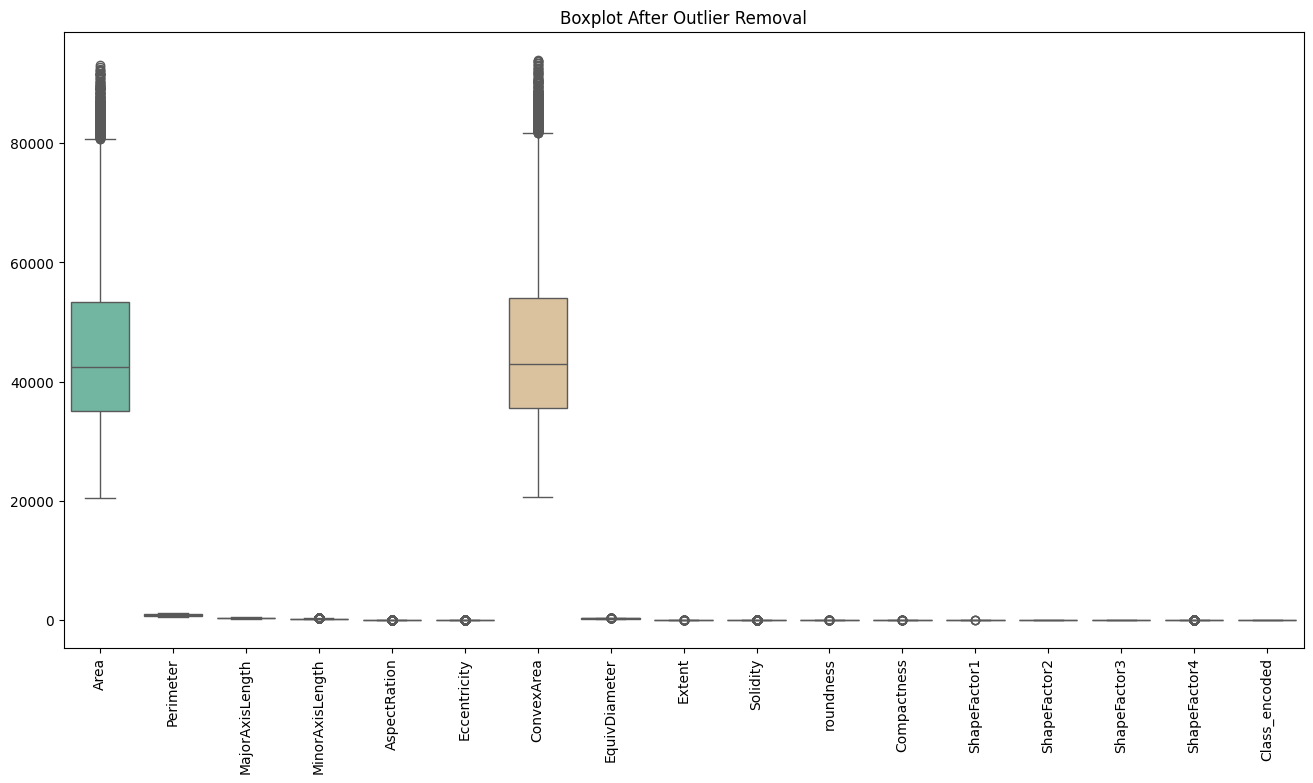

In [28]:
# Histogram
df_cleaned.hist(figsize=(16, 12), bins=30, color="green", edgecolor="black")
plt.suptitle("Feature Distributions After Outlier Removal")
plt.tight_layout()
plt.show()

# Boxplot
plt.figure(figsize=(16, 8))
sns.boxplot(data=df_cleaned, palette="Set2")
plt.title("Boxplot After Outlier Removal")
plt.xticks(rotation=90)
plt.show()


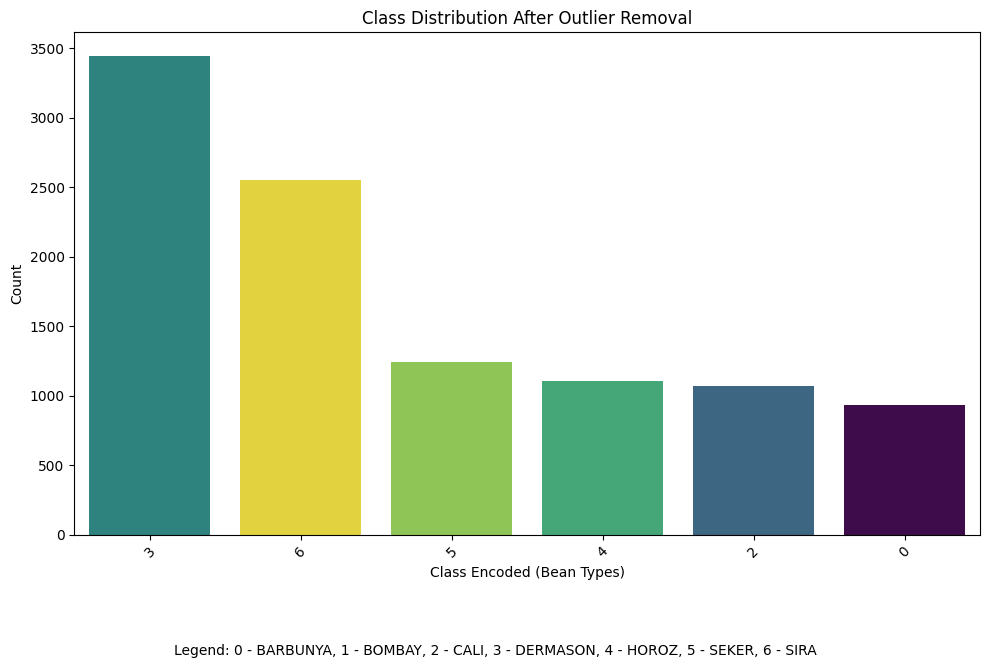

In [29]:
# Create a dictionary mapping encoded values to bean names
class_mapping = dict(zip(label_encoder.transform(label_encoder.classes_), label_encoder.classes_))

# Plot the graph with encoded values
plt.figure(figsize=(10, 6))
sns.countplot(x='Class_encoded', data=df_cleaned, hue='Class_encoded',palette="viridis", order=df_cleaned['Class_encoded'].value_counts().index)
plt.title('Class Distribution After Outlier Removal')
plt.xlabel('Class Encoded (Bean Types)')
plt.ylabel('Count')

# Add a custom legend for the class names
legend_labels = [f"{key} - {value}" for key, value in class_mapping.items()]
plt.figtext(0.5, -0.1, "Legend: " + ", ".join(legend_labels), wrap=True, horizontalalignment='center', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend([], [], frameon=False) 
plt.show()

In [30]:
# Adding a new feature: Compactness_Feature
df_cleaned['Compactness_Feature'] = (4 * np.pi * df_cleaned['Area']) / (df_cleaned['Perimeter'] ** 2)

# Display the first few rows to confirm the new feature
df_cleaned[['Area', 'Perimeter', 'Compactness_Feature']].head()


,Area,Perimeter,Compactness_Feature
23,31637,656.711,0.921842
24,31675,657.431,0.920929
29,31811,642.092,0.969600
31,31823,662.532,0.911040
32,31837,656.404,0.928538


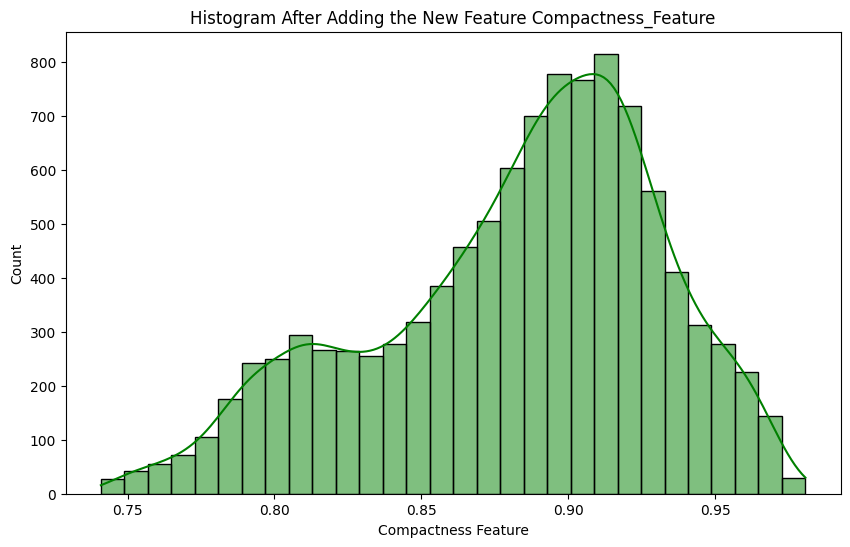

In [31]:
# Visualizing the new feature Compactness_Feature
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['Compactness_Feature'], kde=True, bins=30, color="green")
plt.title('Histogram After Adding the New Feature Compactness_Feature')
plt.xlabel('Compactness Feature')
plt.ylabel('Count')
plt.show()


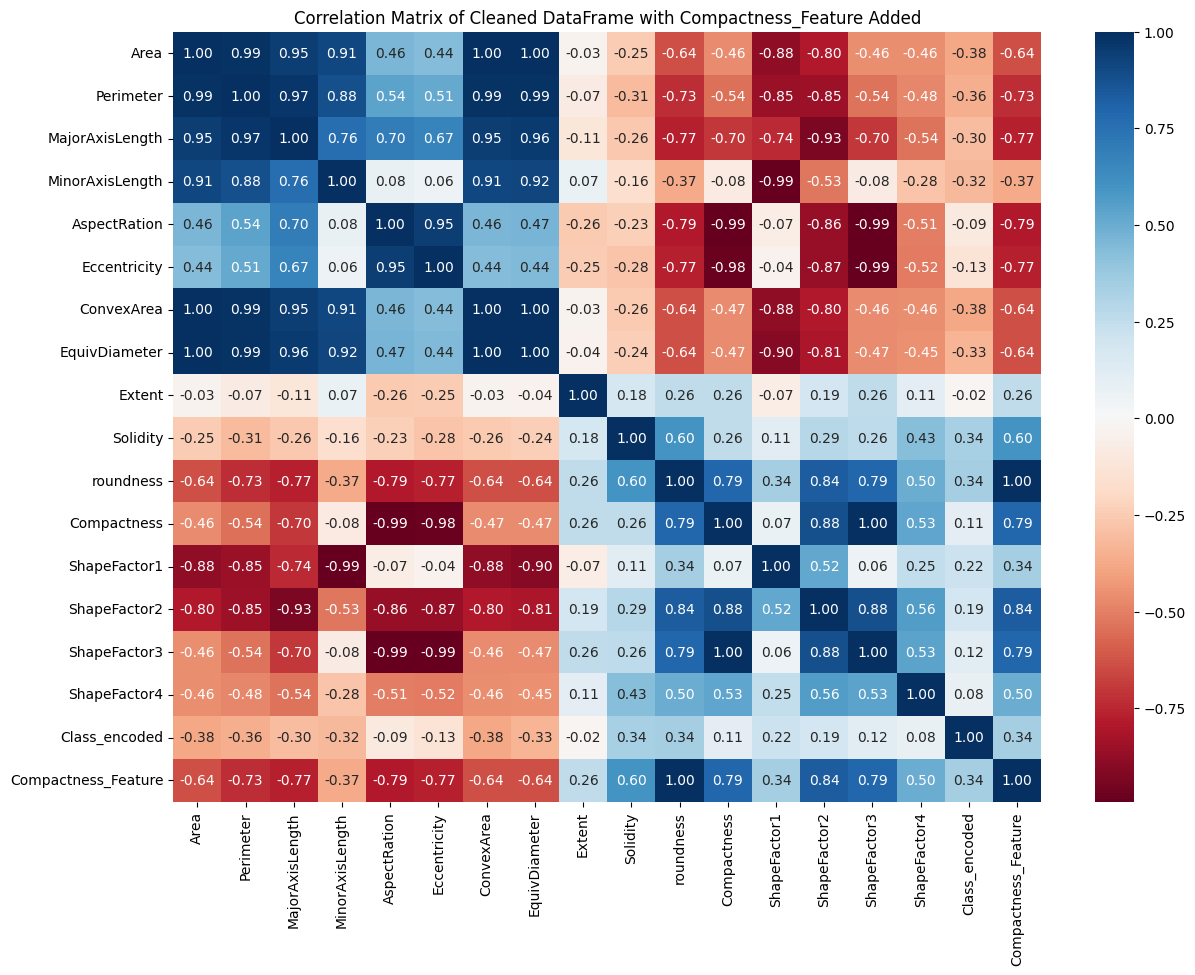

In [32]:
# Recalculate the correlation matrix
correlation_matrix = df_cleaned.corr()

# Visualize the updated correlation matrix
plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap="RdBu", 
    fmt=".2f", 
    cbar=True
)
plt.title('Correlation Matrix of Cleaned DataFrame with Compactness_Feature Added')
plt.show()


In [33]:
df_cleaned.head(1) 

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class_encoded,Compactness_Feature
23,31637,656.711,229.719255,175.510446,1.308864,0.645191,32045,200.702465,0.761823,0.987268,0.921842,0.873686,0.007261,0.00261,0.763327,0.999091,5,0.921842


In [34]:
df_cleaned.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class_encoded,Compactness_Feature
count,10344.000000,10344.000000,10344.000000,10344.000000,10344.000000,10344.000000,10344.000000,10344.000000,10344.000000,10344.000000,10344.000000,10344.000000,10344.000000,10344.000000,10344.000000,10344.000000,10344.000000,10344.000000
mean,46130.783546,803.653515,301.165011,191.700396,1.568731,0.754253,46696.735112,239.285620,0.751748,0.988115,0.882252,0.801731,0.006798,0.001777,0.645350,0.996052,3.714230,0.882252
std,15201.235230,145.927401,60.676963,27.243210,0.204817,0.070602,15430.017649,38.445711,0.044333,0.002776,0.049190,0.050777,0.000927,0.000502,0.080910,0.002410,1.792409,0.049190
min,20420.000000,524.736000,183.601165,138.867330,1.216650,0.569590,20684.000000,161.243764,0.612792,0.979243,0.740893,0.680445,0.004830,0.000816,0.463006,0.988972,0.000000,0.740893
25%,35084.000000,692.975000,252.367272,172.188615,1.439599,0.719360,35489.250000,211.353581,0.719654,0.986633,0.851473,0.772581,0.006246,0.001349,0.596882,0.994679,3.000000,0.851473
50%,42414.500000,770.755500,285.434611,188.644131,1.538729,0.760031,42878.500000,232.387217,0.758108,0.988559,0.891355,0.804743,0.006777,0.001791,0.647611,0.996673,3.000000,0.891355
75%,53327.500000,900.807500,349.349675,204.508148,1.666468,0.799946,54003.250000,260.573755,0.787207,0.990052,0.917661,0.832206,0.007421,0.002168,0.692567,0.997919,5.000000,0.917661
max,93235.000000,1199.087000,472.035963,264.610893,2.138584,0.883941,94031.000000,344.543885,0.866195,0.994260,0.980751,0.906257,0.009188,0.003312,0.821302,0.999733,6.000000,0.980751


<div style="text-align: center;">
    <h3 style="color: black; font-weight: bold;">Baselines and Learning Curves</h3>
</div>

We need to prepare the dataset for cross-validation.
The evaluation metric is based on quality measures from Task 1 ( **accuracy** and **F1 score**).

In [35]:
# Split the dataset into training and test sets
X = df_cleaned.drop('Class_encoded', axis=1)
y = df_cleaned['Class_encoded']

# Stratified split to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Set up a StratifiedKFold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


The baseline can be a dummy classifier (e.g., predicting the most frequent class).
This will serve as a reference to evaluate the performance of machine learning algorithms.

In [36]:
# Baseline model: Most frequent class
baseline_model = DummyClassifier(strategy='most_frequent')
baseline_model.fit(X_train, y_train)

# Evaluate baseline on test set
baseline_predictions = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)
baseline_f1 = f1_score(y_test, baseline_predictions, average='weighted')

print(f"Baseline Accuracy: {baseline_accuracy:.2f}")
print(f"Baseline F1 Score: {baseline_f1:.2f}")


Baseline Accuracy: 0.33
Baseline F1 Score: 0.17


In [37]:

# Algorithm A1: Decision Tree
param_range_tree = range(1, 21)  # Values for max_depth
train_scores_tree, test_scores_tree = validation_curve(
    DecisionTreeClassifier(random_state=42),
    X_train, y_train,
    param_name="max_depth",
    param_range=param_range_tree,
    scoring="accuracy",
    cv=cv
)

# Algorithm A2: Random Forest
param_range_forest = range(10, 210, 20)  # Values for n_estimators
train_scores_forest, test_scores_forest = validation_curve(
    RandomForestClassifier(random_state=42),
    X_train, y_train,
    param_name="n_estimators",
    param_range=param_range_forest,
    scoring="accuracy",
    cv=cv
)


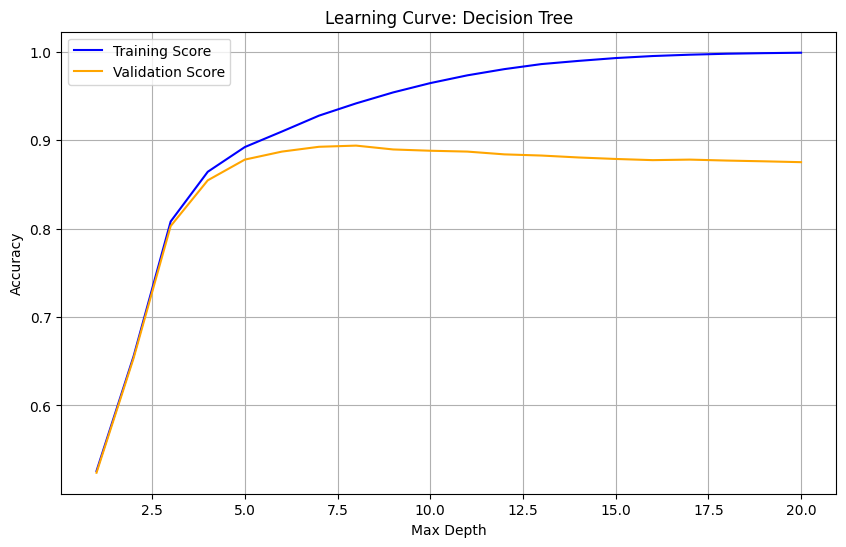

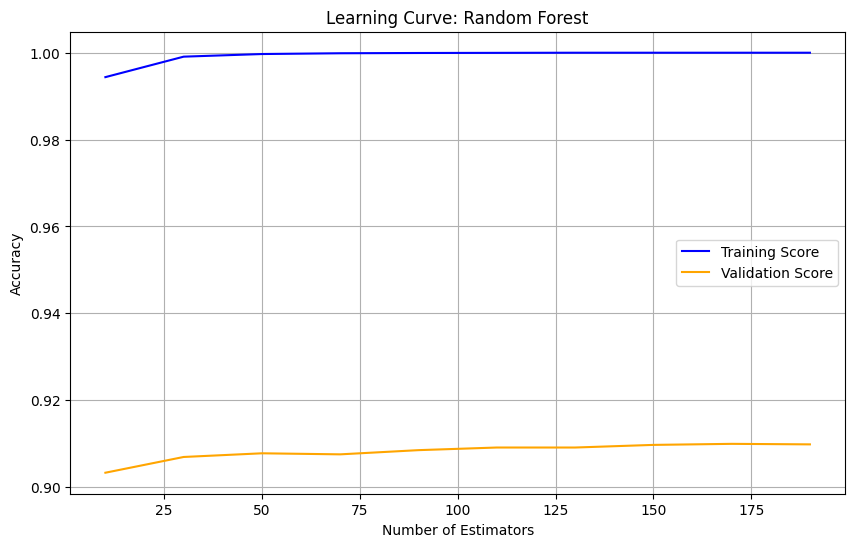

In [38]:


# Plot Decision Tree learning curve
plt.figure(figsize=(10, 6))
plt.plot(param_range_tree, np.mean(train_scores_tree, axis=1), label="Training Score", color="blue")
plt.plot(param_range_tree, np.mean(test_scores_tree, axis=1), label="Validation Score", color="orange")
plt.title("Learning Curve: Decision Tree")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

# Plot Random Forest learning curve
plt.figure(figsize=(10, 6))
plt.plot(param_range_forest, np.mean(train_scores_forest, axis=1), label="Training Score", color="blue")
plt.plot(param_range_forest, np.mean(test_scores_forest, axis=1), label="Validation Score", color="orange")
plt.title("Learning Curve: Random Forest")
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()


In [39]:
# Baseline performance
print(f"Baseline Accuracy: {baseline_accuracy:.2f}")
print(f"Baseline F1 Score: {baseline_f1:.2f}")

# Decision Tree and Random Forest performance comparison
tree_best_depth = param_range_tree[np.argmax(np.mean(test_scores_tree, axis=1))]
forest_best_n_estimators = param_range_forest[np.argmax(np.mean(test_scores_forest, axis=1))]

print(f"Best Decision Tree Depth: {tree_best_depth}")
print(f"Best Random Forest Estimators: {forest_best_n_estimators}")


Baseline Accuracy: 0.33
Baseline F1 Score: 0.17
Best Decision Tree Depth: 8
Best Random Forest Estimators: 170


**Baseline Performance**

- Accuracy: 33%
- F1 Score: 17%

These values represent the initial baseline performance without using trained machine learning models. They help evaluate how much the models improve the classification results.

**Best Hyperparameters**

**Decision Tree**

The best maximum depth was **8**. Validation accuracy improved until depth 8, but decreased slightly after this point. This suggests that deeper trees started to overfit the training data.

**Random Forest**

The best number of estimators was **170**. After 170 estimators, validation accuracy did not improve significantly. Therefore, 170 was a good balance between performance and computational cost.

**Learning Curves**

**Decision Tree**

As the tree depth increased, training accuracy approached 1.0, which indicates overfitting. The best validation accuracy was reached at depth **8**, where the model had a good balance between simplicity and complexity.

**Random Forest**

Training accuracy remained very high for different numbers of estimators. Validation accuracy improved as the number of estimators increased and became stable around **170**.

**Conclusion**

Both models performed much better than the baseline. The Decision Tree model was faster and simpler, but more prone to overfitting. Random Forest was more stable and achieved stronger performance on this dataset.

<div style="text-align: center;">
    <h3 style="color: black; font-weight: bold;"> Nested Cross Validation</h3>
</div>

**Nested Cross-Validation:**

 The process involved:

 ●Inner Loop: Optimized hyperparameters using GridSearchCV with 3-fold cross-validation.

 ●Outer Loop: Evaluated model performance on unseen data using 5-fold cross-validation.
 
 **Evaluation Metrics:**
 Two metrics, **accuracy** and **F1 score**, were used to assess model performance. These metrics help to measure how well the models generalize to new data and handle class imbalances.

 **Baseline Model:**
 A baseline classifier (predicting the most frequent class) was used for comparison. This ensures that our models (A1 and A2) outperform a simple strategy.

In [ ]:
# Define hyperparameter grids
dt_param_grid = {
    'max_depth': [6, 8, 10],  # we identified that the optimal max_depth for the Decision Tree is 8 before
    'min_samples_split': [2, 5, 10]
}

rf_param_grid = {
    'n_estimators': [150, 170, 190],  ##Before we identified that the optimal range for n_estimators in the Random Forest is around 170.
    'max_depth': [10, 20, None]
}

In [41]:
# Outer cross-validation
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store results
dt_train_scores, dt_test_scores = [], []
rf_train_scores, rf_test_scores = [], []

In [42]:
# Nested cross-validation
for train_idx, test_idx in outer_cv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # GridSearchCV for Decision Tree
    rf_inner_cv = GridSearchCV(
        estimator=DecisionTreeClassifier(random_state=42),
        param_grid=dt_param_grid,
        scoring='accuracy',
        cv=3,  # Inner cross-validation
        n_jobs=-1
    )
    rf_inner_cv.fit(X_train, y_train)
    dt_best_model =  rf_inner_cv.best_estimator_
    dt_train_scores.append(accuracy_score(y_train, dt_best_model.predict(X_train)))
    dt_test_scores.append(accuracy_score(y_test, dt_best_model.predict(X_test)))
    
    # GridSearchCV for Random Forest
    rf_inner_cv = GridSearchCV(
        estimator=RandomForestClassifier(random_state=42),
        param_grid=rf_param_grid,
        scoring='accuracy',
        cv=3,  # Inner cross-validation
        n_jobs=-1
    )
    rf_inner_cv.fit(X_train, y_train)
    rf_best_model =  rf_inner_cv.best_estimator_
    rf_train_scores.append(accuracy_score(y_train, rf_best_model.predict(X_train)))
    rf_test_scores.append(accuracy_score(y_test, rf_best_model.predict(X_test)))

In [43]:
# Calculate averages
dt_avg_train_score = np.mean(dt_train_scores)
dt_avg_test_score = np.mean(dt_test_scores)
rf_avg_train_score = np.mean(rf_train_scores)
rf_avg_test_score = np.mean(rf_test_scores)

# Print results
print(f"Decision Tree: Avg Train Accuracy: {dt_avg_train_score:.3f}, Avg Test Accuracy: {dt_avg_test_score:.3f}")
print(f"Random Forest: Avg Train Accuracy: {rf_avg_train_score:.3f}, Avg Test Accuracy: {rf_avg_test_score:.3f}")

Decision Tree: Avg Train Accuracy: 0.925, Avg Test Accuracy: 0.895
Random Forest: Avg Train Accuracy: 0.962, Avg Test Accuracy: 0.911


In [44]:
# Create performance table
performance_table = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Train Accuracy': [dt_avg_train_score, rf_avg_train_score],
    'Test Accuracy': [dt_avg_test_score, rf_avg_test_score]
})

print(performance_table)

           Model  Train Accuracy  Test Accuracy
0  Decision Tree        0.925077       0.894625
1  Random Forest        0.962394       0.911349


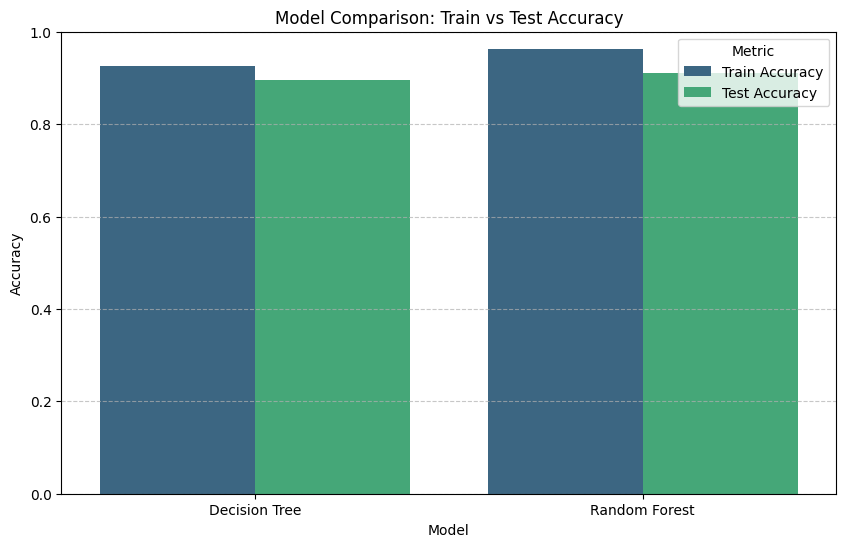

In [ ]:
# Visualize Accuracy
plt.figure(figsize=(10, 6))
sns.barplot(data=performance_table.melt(id_vars='Model', var_name='Metric', value_name='Accuracy'),
            x='Model', y='Accuracy', hue='Metric', palette='viridis')
plt.title('Model Comparison: Train vs Test Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [46]:
# Summarize results
dt_avg_train_score = np.mean(dt_train_scores)
dt_avg_test_score = np.mean(dt_test_scores)
rf_avg_train_score = np.mean(rf_train_scores)
rf_avg_test_score = np.mean(rf_test_scores)

print(f"Decision Tree: Avg Train Accuracy: {dt_avg_train_score:.3f}, Avg Test Accuracy: {dt_avg_test_score:.3f}")
print(f"Random Forest: Avg Train Accuracy: {rf_avg_train_score:.3f}, Avg Test Accuracy: {rf_avg_test_score:.3f}")


Decision Tree: Avg Train Accuracy: 0.925, Avg Test Accuracy: 0.895
Random Forest: Avg Train Accuracy: 0.962, Avg Test Accuracy: 0.911


In [47]:
# Baseline performance (accuracy and F1 score)
baseline_accuracy = 0.33
baseline_f1 = 0.17

# Creating table

performance_table = pd.DataFrame({
    'Model': ['Baseline', 'Decision Tree', 'Random Forest'],
    'Train Accuracy': [baseline_accuracy, dt_avg_train_score, rf_avg_train_score],
    'Test Accuracy': [baseline_accuracy, dt_avg_test_score, rf_avg_test_score],
    'Train F1': [baseline_f1, np.mean(dt_train_scores), np.mean(rf_train_scores)],
    'Test F1': [baseline_f1, np.mean(dt_test_scores), np.mean(rf_test_scores)]
})

print(performance_table)


           Model  Train Accuracy  Test Accuracy  Train F1   Test F1
0       Baseline        0.330000       0.330000  0.170000  0.170000
1  Decision Tree        0.925077       0.894625  0.925077  0.894625
2  Random Forest        0.962394       0.911349  0.962394  0.911349


In [48]:
# Based on the results, comparing test accuracy and F1 scores
if rf_avg_test_score > dt_avg_test_score:
    print("Random Forest outperforms Decision Tree and is the recommended model.")
else:
    print("Decision Tree outperforms Random Forest and is the recommended model.")


Random Forest outperforms Decision Tree and is the recommended model.


**Model Comparisons: Train vs. Test Accuracy and F1 Scores**

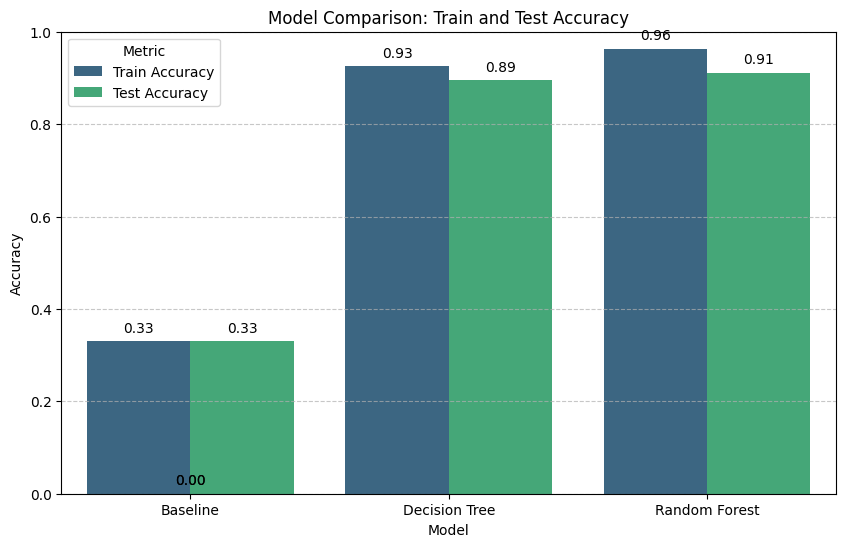

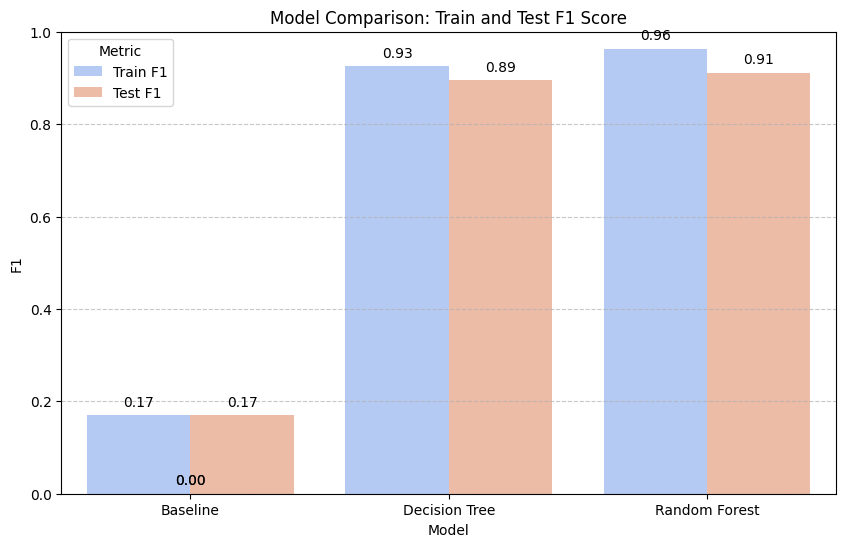

In [49]:
accuracy_melted = performance_table.melt(id_vars='Model', value_vars=['Train Accuracy', 'Test Accuracy'], 
                                         var_name='Metric', value_name='Accuracy')
f1_melted = performance_table.melt(id_vars='Model', value_vars=['Train F1', 'Test F1'], 
                                   var_name='Metric', value_name='F1 Score')
# Plot Accuracy with values on top
plt.figure(figsize=(10, 6))
sns.barplot(data=accuracy_melted, x='Model', y='Accuracy', hue='Metric', palette='viridis')
plt.title('Model Comparison: Train and Test Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of bars
for i, bar in enumerate(plt.gca().patches):
    plt.text(bar.get_x() + bar.get_width() / 2, 
             bar.get_height() + 0.02,  
             f"{bar.get_height():.2f}", 
             ha='center', fontsize=10)

plt.show()

# Plot F1 Score with values on top
plt.figure(figsize=(10, 6))
sns.barplot(data=f1_melted, x='Model', y='F1 Score', hue='Metric', palette='coolwarm')
plt.title('Model Comparison: Train and Test F1 Score')
plt.ylabel('F1')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of bars
for i, bar in enumerate(plt.gca().patches):
    plt.text(bar.get_x() + bar.get_width() / 2, 
             bar.get_height() + 0.02,  
             f"{bar.get_height():.2f}", 
             ha='center', fontsize=10)

plt.show()


 **Outcomes**

 The result show clear differences between the baseline model, Decision Tree (A1), and Random Forest (A2).
 
 **Baseline Performance:**

 ●The baseline model had an accuracy of 33% and an F1 score of 17%. This model only predicts the most common class in the data, so it cannot handle more complex patterns,  only used as a basic comparison.
 
 **Decision Tree (A1):**
 
 ●The Decision Tree gave a 92.5% train accuracy and an 89.5% test accuracy. 

 ●The small gap between the two shows that the model can generalize well and is not overfitting. However, it did not perform as well as Random Forest.
 

 **Random Forest (A2):**

 ●Random Forest performed better than Decision Tree, with a 96.2% train accuracy and a 91.1% test accuracy. 

 ●Random Forest works by combining many decision trees, which makes it more stable and accurate, especially for complex datasets.

 
 **Train-Test Gap:**
 The gap between train and test accuracy was small for both models:

 Decision Tree: A gap of about 3%.
 Random Forest: A gap of about 5%.
 This means that both models are reliable and can make good predictions on new data.


 **Model Comparison:**

 While Decision Tree is simpler and faster, Random Forest gave better results in accuracy and F1 score. Random Forest is a stronger model when the data is more complex

 **Conclusion**

 ●Overall, Random Forest (A2) is the best model for this task because it gave the highest accuracy and F1 scores. Decision Tree (A1) is still a good option, but Random Forest is better for making accurate predictions. 
 
 ●These results show that more advanced models can give better results when the data is complex.Therefore, I chose **Random Forest** as the final model for this project.


<div style="text-align: center;">
    <h3 style="color: black; font-weight: bold;"> Analysis of the Final Model</h3>
</div>



This part focuses on evaluating the final model and understanding its predictions. Below are the main steps involved:

- **Evaluate Predictions:** Analyze how well the model performs for each class using metrics such as precision, recall, and F1-score.  
- **Combine Results:** Gather predictions from all folds in the outer cross-validation for a complete evaluation.  
- **Visualize Performance:** Use visual tools like the confusion matrix and bar charts to display the model’s results across classes.  
- **Class Analysis:** Examine which classes are predicted well and where the model struggles.  
- **Conclusion:** Summarize the analysis and highlight areas for potential improvement.  


In [50]:
#Collecting Predictions from Outer CV
y_true_all = []
y_pred_all = []
for train_idx, test_idx in outer_cv.split(df_cleaned):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    rf_inner_cv.fit(X_train, y_train)
    y_pred = rf_inner_cv.best_estimator_.predict(X_test)
    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)


In [51]:
label_encoder = LabelEncoder()
label_encoder.fit(y_true_all)


class_report = classification_report(
    y_true_all,
    y_pred_all,
    target_names=label_encoder.classes_,  # Updated class names

    output_dict=True
)
class_report_df = pd.DataFrame(class_report).transpose()
class_report_df

,precision,recall,f1-score,support
0,0.941176,0.875536,0.907171,932.00000
2,0.910747,0.937207,0.923788,1067.00000
3,0.912216,0.932888,0.922436,3442.00000
4,0.958993,0.929539,0.944037,1107.00000
5,0.923825,0.916399,0.920097,1244.00000
6,0.874216,0.874216,0.874216,2552.00000
accuracy,0.911350,0.911350,0.911350,0.91135
macro avg,0.920196,0.910964,0.915291,10344.00000
weighted avg,0.911701,0.911350,0.911334,10344.00000


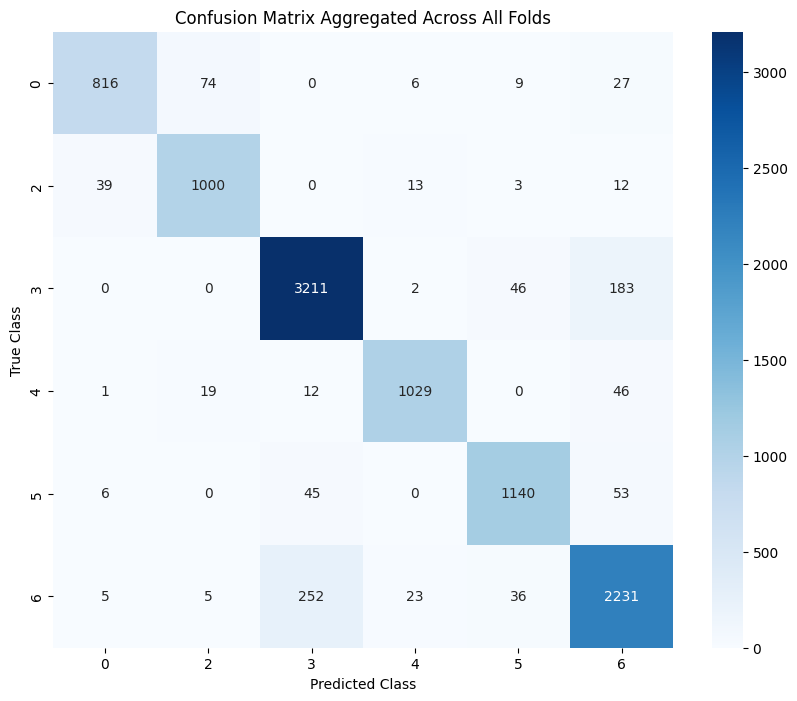

In [52]:
#  Confusion Matrix
conf_matrix = confusion_matrix(y_true_all, y_pred_all)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Confusion Matrix Aggregated Across All Folds')
plt.show()


**1. Best Predicted Class**

●The model performs best for Class 3, with 3211 correct predictions. This is the highest number of correct predictions for any class.

●This means the model can identify Class 3 examples very well.

**2. Second Best Predicted Class**

●Class 6 comes next, with 2231 correct predictions. 

●This is also a strong performance, but there is some confusion with other classes, especially Class 3, where 252 examples from Class 6 were wrongly predicted as Class 3.

**3. Most Confused Classes**

●The biggest confusion happens between Class 6 and Class 3.

●Many examples from Class 6 are predicted as Class 3.

●Similarly, Class 0 has some confusion with Class 2 (74 
examples) and Class 6 (27 examples).


**4. General Performance**

Overall, the model predicts most classes correctly, as seen in the high numbers on the diagonal of the matrix.

However, the confusion between certain classes, like Class 6 and Class 3, could be improved with better feature engineering or parameter tuning.




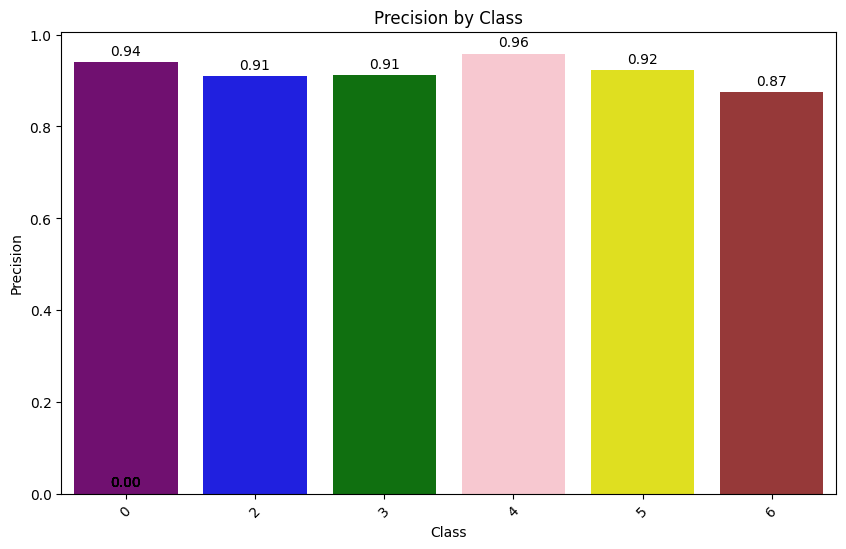

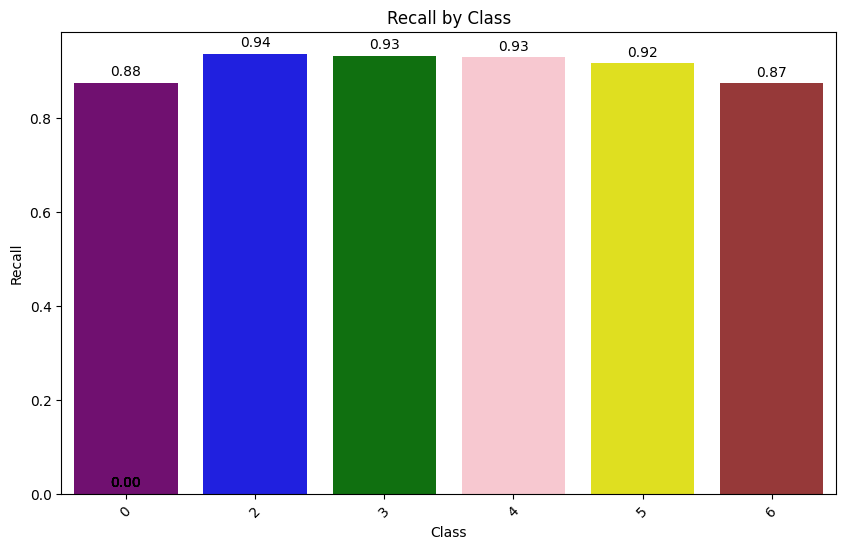

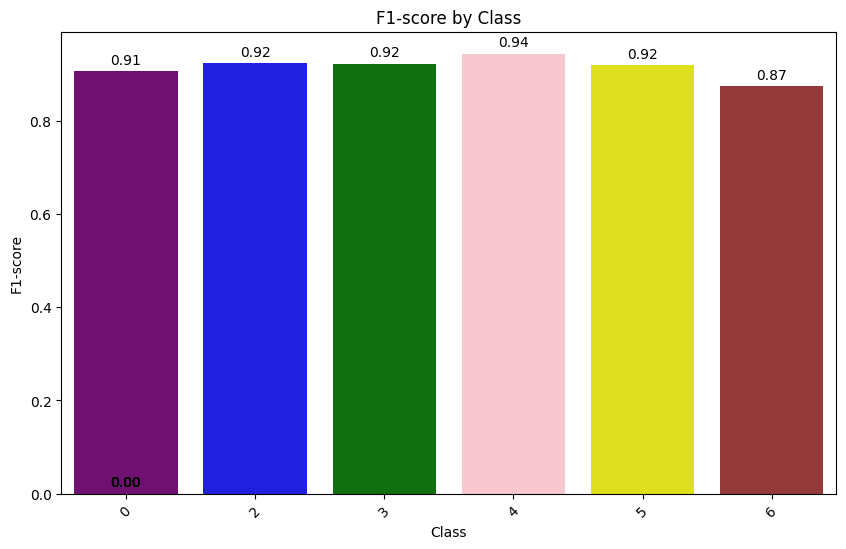

In [53]:
# Visualize Precision, Recall, and F1 Scores
metrics = ['precision', 'recall', 'f1-score']

for metric in metrics:
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        x=class_report_df.iloc[:6].index,  
        y=class_report_df[metric].iloc[:6], 
        hue=class_report_df.iloc[:6].index, 
        palette=[encoded_colours[class_idx] for class_idx in class_report_df.iloc[:6].index]  
    )
    
    # Add values on top of the bars
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}',  
                    (p.get_x() + p.get_width() / 2., p.get_height()),  
                    ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5), 
                    textcoords='offset points')  
    
    plt.title(f'{metric.capitalize()} by Class')
    plt.xlabel('Class')
    plt.ylabel(metric.capitalize())
    plt.xticks(rotation=45)
    plt.legend([], [], frameon=False)  
    plt.show()


**Comments about Precision, Recall, and F1-Score Graphs**

**Precision:**

Class 4 has the highest precision (95.8%), meaning the model makes very few false predictions for this class.

Class 6 has the lowest precision (87.4%), showing that the model sometimes predicts Class 6 incorrectly.

**Recall:**

Class 2 has the best recall (93.7%), so the model successfully finds most of the examples for this class. 

Class 6 again has the lowest recall (87.4%), meaning the model misses some examples from this class.

**F1-Score:**

Class 4 has the highest F1-score (94.4%), showing balanced precision and recall.

Class 6 has the lowest F1-score (87.4%), showing weaker performance compared to other classes.

**Conclusion:**

The model performs very well for Class 3 and Class 4, which have the best metrics in precision, recall, and F1-score.
However, Class 6 needs improvement. It has the lowest metrics and shows confusion with other classes, especially Class 3.
Overall, the model is strong but could be improved to better separate similar classes.

These metrics align with the Confusion Matrix, where Class 6 shows confusion with Class 3.



In [54]:
print("True Labels:", set(y_true_all))
print("Predicted Labels:", set(y_pred_all))


True Labels: {0, 2, 3, 4, 5, 6}
Predicted Labels: {0, 2, 3, 4, 5, 6}


In [55]:
print("Classification Report:")
print(classification_report(y_true_all, y_pred_all))


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.88      0.91       932
           2       0.91      0.94      0.92      1067
           3       0.91      0.93      0.92      3442
           4       0.96      0.93      0.94      1107
           5       0.92      0.92      0.92      1244
           6       0.87      0.87      0.87      2552

    accuracy                           0.91     10344
   macro avg       0.92      0.91      0.92     10344
weighted avg       0.91      0.91      0.91     10344



In [56]:
print("First 20 True Labels:", y_true_all[:20])
print("First 20 Predicted Labels:", y_pred_all[:20])


First 20 True Labels: [5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5]
First 20 Predicted Labels: [3 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5]


<div style="text-align: center;">
    <h3 style="color: black; font-weight: bold;">Conclusions and Future Work</h3>
</div>

 **1.Summary**

 **The Random Forest** 

 The Random Forest model performed best overall, with an accuracy of 91.2%. It also showed high precision, recall, and F1-scores for most classes. From the class analysis, most classes were correctly predicted, but Class 6 had slightly lower recall due to confusion with Class 3, as seen in the confusion matrix. The results from nested cross-validation confirm that Random Forest is suitable for this task

 **2.Explanation of Generated Value**

 Classifying dry bean types accurately is valuable for farmers and producers. It reduces sorting mistakes, saves time, and improves efficiency. Using the Random Forest model can lower labor costs, help with inventory management, and ensure better product quality. These improvements lead to higher customer satisfaction and trust in the market.

 **3.Future Work**

 1. **Feature Engineering:**  
   - We might improve the model by adding new features, such as texture or shape measurements. These features may help the model separate similar classes, especially Class 6 and Class 3.

 2. **Balancing Classes:**  
   - We can use techniques like SMOTE or oversampling to balance the dataset. This might improve recall for underrepresented classes and reduce confusion between similar ones.

 3. **Trying New Algorithms:**  
   - We may experiment with Gradient Boosting models, like XGBoost or LightGBM. These models might handle overlapping classes better and improve overall performance.

 4. **Collaborating with Experts:**  
   - Working with domain experts might help us find important features or transformations that we did not consider. This could improve the model’s accuracy and make it easier to interpret.

 5. **Expanding the Dataset:**  
   - Collecting more data for minority classes may help the model learn better and reduce errors. It might also make the dataset more diverse and realistic.


 **4. Critical Reflection**

 Strengths:

 Nested cross-validation ensured reliable results and avoided overfitting during model tuning.
 Visual tools like the confusion matrix made it easy to see which classes were predicted well and which had issues.

 *Limitations:*

 Removing outliers might have excluded rare but important examples, reducing the dataset’s variety.
 Random Forest is less interpretable, which might be a problem for stakeholders who need clear explanations.

 *What Could Be Improved:*

 Feature engineering could have helped the model handle similar classes better.
 Balancing the class distribution earlier might have improved recall for underrepresented classes.
 
 *Were the Goals Realistic?*

 Yes, the goal of creating an accurate and automated classification model was realistic and achieved. However, perfect predictions for all classes would require deeper adjustments and more domain-specific insights.